# 📡 DoNext 5G — NB4_DSO3 : Prédiction Next Best Cell

**Pipeline :** NB1 ✅ → NB2 ✅ → NB3 ✅ → DSO1 ✅ → DSO2 ✅ → **NB4_DSO3**

Stratégie : Top-N cellules + Top-K accuracy | Matrices de confusion par modèle

| # | Modèle | Type |
|---|--------|------|
| M1 | XGBoost | Classique |
| M2 | LightGBM | Classique |
| M3 | Random Forest | Classique |
| M4 | LSTM Softmax | Deep Learning |
| M5 | TabNet (pré-entraîné) | Pré-entraîné |

---
## Section 0 — Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import json, os, gc, pickle, warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    f1_score, accuracy_score, top_k_accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from pytorch_tabnet.tab_model import TabNetClassifier
from pytorch_tabnet.pretraining import TabNetPretrainer
import torch

plt.rcParams.update({'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D27','axes.edgecolor':'#3A3D4D',
    'axes.labelcolor':'#E0E0E0','axes.titlecolor':'#FFFFFF','xtick.color':'#B0B0B0',
    'ytick.color':'#B0B0B0','text.color':'#E0E0E0','grid.color':'#2A2D3A',
    'grid.linestyle':'--','grid.alpha':0.5,'font.family':'monospace','figure.dpi':130})
BLUE='#4FC3F7'; GREEN='#69F0AE'; ORANGE='#FFB74D'; RED='#EF5350'; PURPLE='#CE93D8'

DATASET_ROOT  = r'C:\Users\THINKPAD\Desktop\DATASET'  # ← adapter
PT_OUT_DIR    = os.path.join(DATASET_ROOT,'PT_output')
FE_DATA_DIR   = os.path.join(DATASET_ROOT,'FE_data')
MODEL_OUT_DIR = os.path.join(DATASET_ROOT,'MODEL_output','DSO3')
os.makedirs(MODEL_OUT_DIR, exist_ok=True)
TOP_N_CELLS=50; TOP_K_EVAL=3
print(f'✅ Setup OK | TOP_N={TOP_N_CELLS} | TOP_K={TOP_K_EVAL}')

✅ Setup OK | TOP_N=50 | TOP_K=3


---
## Section 1 — Construction du Label Next Cell

In [2]:
CONFIGS={'static':'session_id','mobile':'device','hbahn':'device'}
df_ho=pd.read_parquet(os.path.join(FE_DATA_DIR,'df_ho.parquet'),
    columns=['session_id','device','source_folder','cell_index','handover'])
df_ho['next_cell']=np.nan
for env,cle in CONFIGS.items():
    if cle not in df_ho.columns: continue
    mask_env=df_ho['source_folder']==env
    for name,grp in df_ho[mask_env].groupby(cle):
        df_ho.loc[grp.index,'next_cell']=grp['cell_index'].shift(-1)
df_ho_only=df_ho[df_ho['handover']==1].dropna(subset=['next_cell'])
print(f'Handovers avec next_cell : {len(df_ho_only):,}')
cell_counts=df_ho_only['next_cell'].value_counts()
top_cells=cell_counts.head(TOP_N_CELLS).index.tolist()
coverage=cell_counts.head(TOP_N_CELLS).sum()/cell_counts.sum()*100
print(f'Top-{TOP_N_CELLS} couvre {coverage:.1f}% des HO')
df_filtered=df_ho_only[df_ho_only['next_cell'].isin(top_cells)].copy()
le=LabelEncoder()
df_filtered['next_cell_enc']=le.fit_transform(df_filtered['next_cell'].astype(str))
N_CLASSES=len(le.classes_)
with open(os.path.join(MODEL_OUT_DIR,'label_encoder_cells.pkl'),'wb') as f: pickle.dump(le,f)
print(f'{N_CLASSES} classes | {len(df_filtered):,} handovers retenus')

Handovers avec next_cell : 223,141
Top-50 couvre 58.8% des HO
50 classes | 131,167 handovers retenus


In [3]:
# ── Chargement mémoire-safe ─────────────────────────────────
with open(os.path.join(PT_OUT_DIR,'config.json')) as f: config=json.load(f)
COLS_X=[c for c in config['cols_X']]

import pyarrow.parquet as pq
pf = pq.ParquetFile(os.path.join(PT_OUT_DIR,'df_preprocessed.parquet'))
schema_cols = pf.schema_arrow.names
COLS_X = [c for c in COLS_X if c in schema_cols]

common_idx = df_filtered.index[
    df_filtered.index.isin(
        pq.read_table(os.path.join(PT_OUT_DIR,'df_preprocessed.parquet'),
                      columns=[]).to_pandas().index
    )
]
# Lecture colonne-sélective pour économiser la RAM
df_pre = pd.read_parquet(
    os.path.join(PT_OUT_DIR,'df_preprocessed.parquet'),
    columns=COLS_X
)
common_idx = df_filtered.index[df_filtered.index.isin(df_pre.index)]
df_filtered = df_filtered.loc[common_idx]
X_all = df_pre.loc[common_idx, COLS_X].values.astype(np.float32)
y_all = df_filtered['next_cell_enc'].values
del df_pre; gc.collect()

# ── Split STRATIFIÉ (évite les classes absentes du train) ────
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X_all, y_all, test_size=0.15, random_state=42, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42, stratify=y_temp
)
del X_temp, y_temp; gc.collect()

# ── Réencoder proprement sur y_train ────────────────────────
le2 = LabelEncoder()
y_train = le2.fit_transform(y_train)

def align_labels(y_raw, le):
    mapping = {c: i for i, c in enumerate(le.classes_)}
    return np.array([mapping.get(c, -1) for c in y_raw])

y_val  = align_labels(y_val,  le2)
y_test = align_labels(y_test, le2)

# Filtrer les rares cas encore absents (normalement 0 avec stratify)
mask_val  = y_val  != -1
mask_test = y_test != -1
X_val,  y_val  = X_val[mask_val],   y_val[mask_val]
X_test, y_test = X_test[mask_test], y_test[mask_test]

N_CLASSES = len(le2.classes_)
with open(os.path.join(MODEL_OUT_DIR,'label_encoder_cells.pkl'),'wb') as f: pickle.dump(le2,f)
print(f'✅ Split stratifié | {N_CLASSES} classes')
print(f'   train={len(X_train):,} | val={len(X_val):,} | test={len(X_test):,}')
print(f'   X_train {X_train.shape}')


✅ Split stratifié | 50 classes
   train=91,816 | val=19,675 | test=19,676
   X_train (91816, 104)


In [ ]:
# Cette cellule est désormais intégrée dans la cellule de chargement ci-dessus.
# Elle est conservée vide pour ne pas décaler la numérotation.
print('⏭️  Cellule fusionnée avec le chargement — rien à faire ici.')


---
## Section 2 — M1 : XGBoost

In [4]:
print('='*60+'\n  M1 — XGBoost DSO3\n'+'='*60)
xgb_d3=XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softmax', num_class=N_CLASSES,
    eval_metric='mlogloss', early_stopping_rounds=20,
    tree_method='hist', random_state=42, n_jobs=-1,
    use_label_encoder=False
)
xgb_d3.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=30)
y_pred_xgb  = xgb_d3.predict(X_test)
y_proba_xgb = xgb_d3.predict_proba(X_test)
acc_xgb  = accuracy_score(y_test, y_pred_xgb)
topk_xgb = top_k_accuracy_score(y_test, y_proba_xgb, k=TOP_K_EVAL,
                                 labels=np.arange(N_CLASSES))  # ✅ fix
f1_xgb   = f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
metrics_xgb = {'model':'XGBoost','accuracy':round(acc_xgb,4),
               f'top{TOP_K_EVAL}_acc':round(topk_xgb,4),'f1_macro':round(f1_xgb,4)}
print(f'  Acc={acc_xgb:.4f} | Top-{TOP_K_EVAL}={topk_xgb:.4f} | F1-macro={f1_xgb:.4f}')
with open(os.path.join(MODEL_OUT_DIR,'xgb_dso3.pkl'),'wb') as f: pickle.dump(xgb_d3,f)


  M1 — XGBoost DSO3
[0]	validation_0-mlogloss:2.18431
[30]	validation_0-mlogloss:0.68336
[60]	validation_0-mlogloss:0.57037
[90]	validation_0-mlogloss:0.54919
[120]	validation_0-mlogloss:0.54207
[150]	validation_0-mlogloss:0.53944
[180]	validation_0-mlogloss:0.53854
[210]	validation_0-mlogloss:0.53912
[216]	validation_0-mlogloss:0.53914
  Acc=0.7848 | Top-3=0.9732 | F1-macro=0.8482


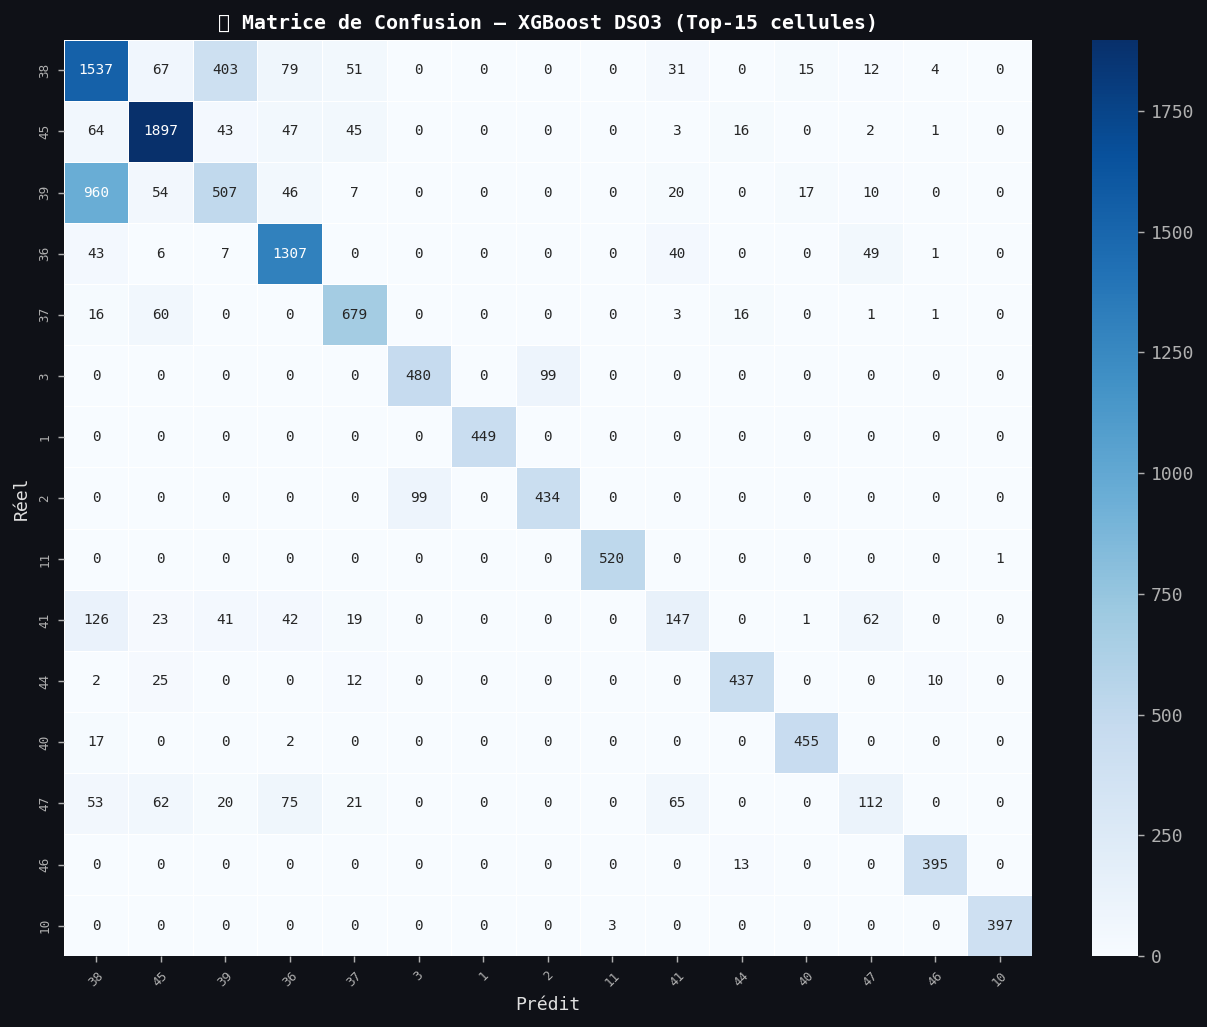

In [5]:
# ── Matrice de Confusion — XGBoost (Top-15 classes) ─────────
top15_cls = pd.Series(y_test).value_counts().head(15).index.tolist()
mask_top  = np.isin(y_test, top15_cls)
cm_xgb    = confusion_matrix(y_test[mask_top], y_pred_xgb[mask_top], labels=top15_cls)
cell_labels = [str(le2.classes_[i])[:8] for i in top15_cls]  # ✅ le2
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
    xticklabels=cell_labels, yticklabels=cell_labels,
    linewidths=0.3, ax=ax, annot_kws={'size':8})
ax.set_xlabel('Prédit', fontsize=10); ax.set_ylabel('Réel', fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', labelsize=7)
ax.set_title('🔢 Matrice de Confusion — XGBoost DSO3 (Top-15 cellules)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_xgb_dso3.png'),
            bbox_inches='tight', facecolor='#0F1117')
plt.show()


---
## Section 3 — M2 : LightGBM

In [7]:
print('='*60+'\n  M2 — LightGBM DSO3\n'+'='*60)
lgbm_d3=LGBMClassifier(
    n_estimators=300, max_depth=7, learning_rate=0.1, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    objective='multiclass', num_class=N_CLASSES,
    metric='multi_logloss', class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_d3.fit(X_train, y_train, eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(30)])
y_pred_lgbm  = lgbm_d3.predict(X_test)
y_proba_lgbm = lgbm_d3.predict_proba(X_test)
acc_lgbm  = accuracy_score(y_test, y_pred_lgbm)
topk_lgbm = top_k_accuracy_score(y_test, y_proba_lgbm, k=TOP_K_EVAL,
                                  labels=np.arange(N_CLASSES))  # ✅ fix
f1_lgbm   = f1_score(y_test, y_pred_lgbm, average='macro', zero_division=0)
metrics_lgbm = {'model':'LightGBM','accuracy':round(acc_lgbm,4),
                f'top{TOP_K_EVAL}_acc':round(topk_lgbm,4),'f1_macro':round(f1_lgbm,4)}
print(f'  Acc={acc_lgbm:.4f} | Top-{TOP_K_EVAL}={topk_lgbm:.4f} | F1-macro={f1_lgbm:.4f}')
with open(os.path.join(MODEL_OUT_DIR,'lgbm_dso3.pkl'),'wb') as f: pickle.dump(lgbm_d3,f)


  M2 — LightGBM DSO3
[30]	valid_0's multi_logloss: 0.653148
[60]	valid_0's multi_logloss: 0.623747
  Acc=0.7638 | Top-3=0.9637 | F1-macro=0.8404


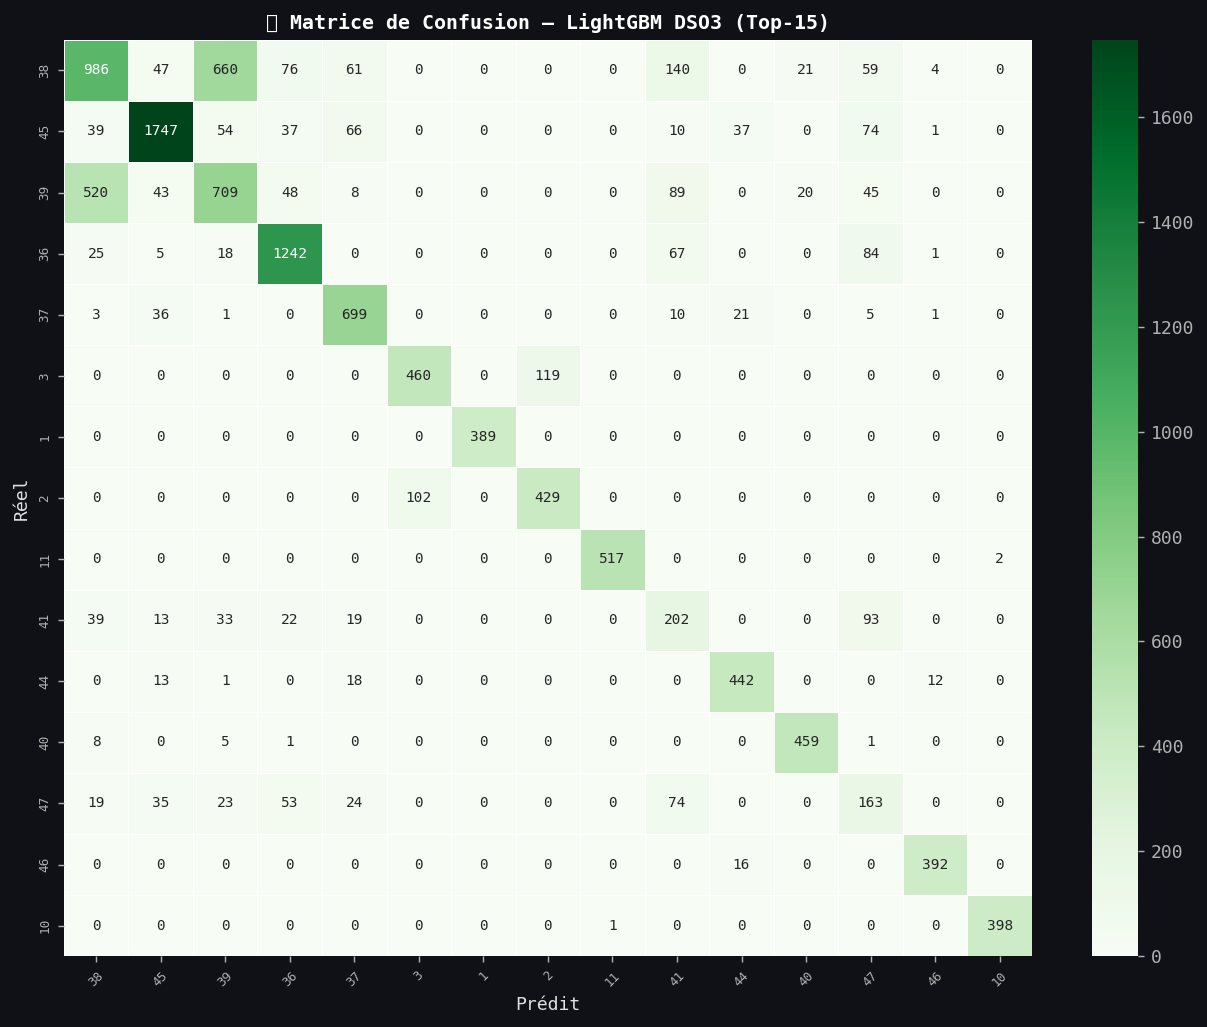

In [8]:
# ── Matrice de Confusion — LightGBM (Top-15) ─────────────────────────────────
cm_lgbm=confusion_matrix(y_test[mask_top],y_pred_lgbm[mask_top],labels=top15_cls)
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_lgbm,annot=True,fmt='d',cmap='Greens',xticklabels=cell_labels,yticklabels=cell_labels,
    linewidths=0.3,ax=ax,annot_kws={'size':8})
ax.set_xlabel('Prédit',fontsize=10); ax.set_ylabel('Réel',fontsize=10)
ax.tick_params(axis='x',rotation=45,labelsize=7); ax.tick_params(axis='y',labelsize=7)
ax.set_title('🔢 Matrice de Confusion — LightGBM DSO3 (Top-15)',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lgbm_dso3.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 4 — M3 : Random Forest

In [9]:
print('='*60+'\n  M3 — Random Forest DSO3\n'+'='*60)
rf_d3=RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=10,
    max_features='sqrt', class_weight='balanced_subsample',
    max_samples=0.3, random_state=42, n_jobs=-1, verbose=1
)
rf_d3.fit(X_train, y_train)
y_pred_rf  = rf_d3.predict(X_test)
y_proba_rf = rf_d3.predict_proba(X_test)
acc_rf  = accuracy_score(y_test, y_pred_rf)
topk_rf = top_k_accuracy_score(y_test, y_proba_rf, k=TOP_K_EVAL,
                                labels=np.arange(N_CLASSES))  # ✅ fix
f1_rf   = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)
metrics_rf = {'model':'Random Forest','accuracy':round(acc_rf,4),
              f'top{TOP_K_EVAL}_acc':round(topk_rf,4),'f1_macro':round(f1_rf,4)}
print(f'  Acc={acc_rf:.4f} | Top-{TOP_K_EVAL}={topk_rf:.4f} | F1-macro={f1_rf:.4f}')
with open(os.path.join(MODEL_OUT_DIR,'rf_dso3.pkl'),'wb') as f: pickle.dump(rf_d3,f)


  M3 — Random Forest DSO3


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    7.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.4s finished


  Acc=0.7318 | Top-3=0.9551 | F1-macro=0.7901


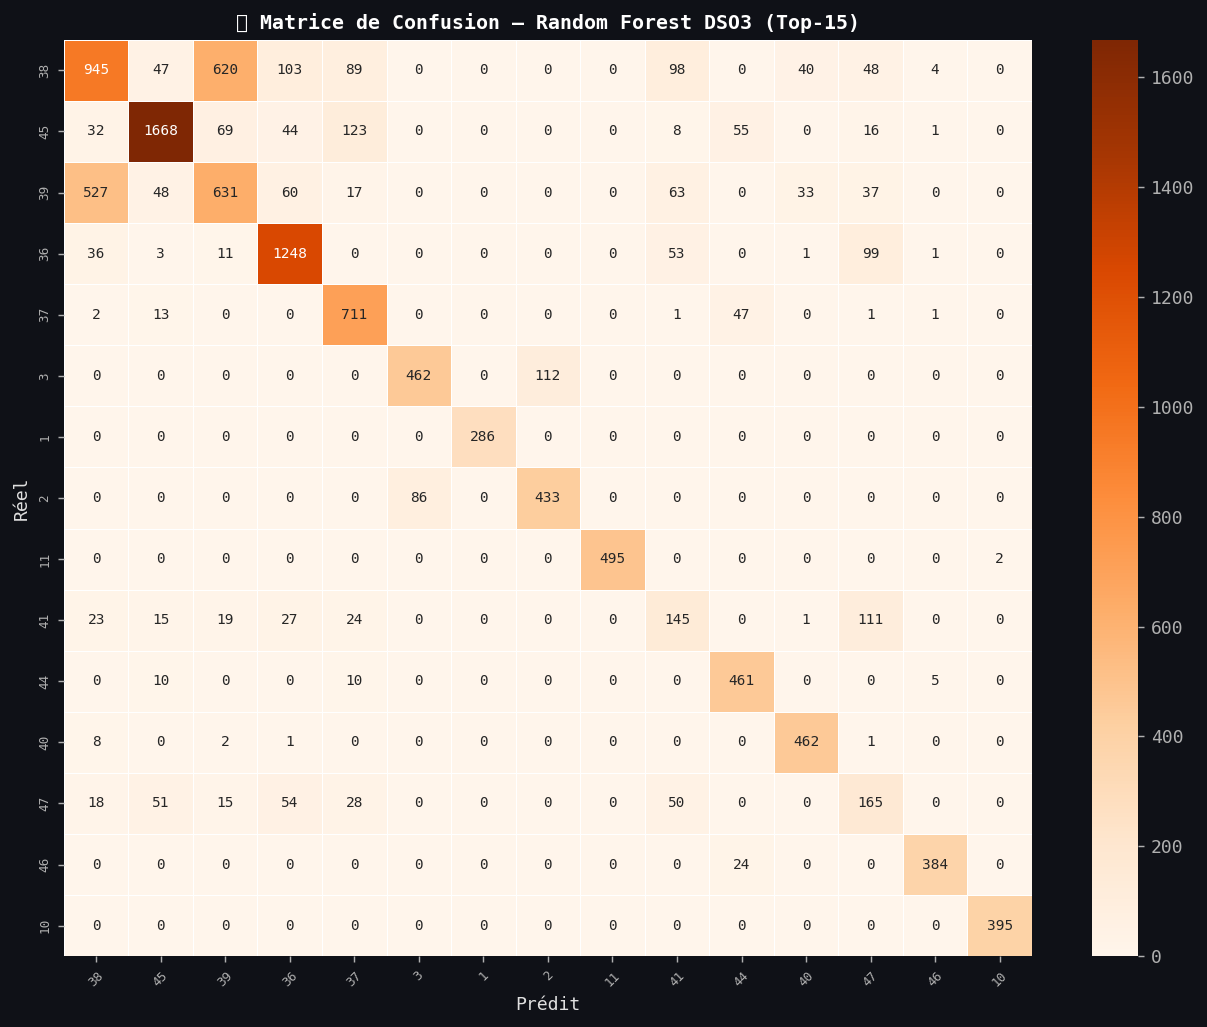

In [10]:
# ── Matrice de Confusion — Random Forest (Top-15) ────────────────────────────
cm_rf=confusion_matrix(y_test[mask_top],y_pred_rf[mask_top],labels=top15_cls)
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Oranges',xticklabels=cell_labels,yticklabels=cell_labels,
    linewidths=0.3,ax=ax,annot_kws={'size':8})
ax.set_xlabel('Prédit',fontsize=10); ax.set_ylabel('Réel',fontsize=10)
ax.tick_params(axis='x',rotation=45,labelsize=7); ax.tick_params(axis='y',labelsize=7)
ax.set_title('🔢 Matrice de Confusion — Random Forest DSO3 (Top-15)',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_rf_dso3.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 5 — M4 : LSTM Softmax (Deep Learning)

In [11]:
print('='*60+'\n  M4 — LSTM Softmax DSO3\n'+'='*60)
WINDOW_COLS=[c for c in COLS_X if any(f'_t-{k}' in c for k in range(1,6))]
T=5 if WINDOW_COLS else 1
if WINDOW_COLS:
    w_idx=[list(COLS_X).index(c) for c in WINDOW_COLS]; F=len(w_idx)//T
    X_tr_3d=X_train[:,w_idx].reshape(-1,T,F)
    X_va_3d=X_val[:,w_idx].reshape(-1,T,F)
    X_te_3d=X_test[:,w_idx].reshape(-1,T,F)
else:
    F=X_train.shape[1]; T=1
    X_tr_3d=X_train.reshape(-1,1,F)
    X_va_3d=X_val.reshape(-1,1,F)
    X_te_3d=X_test.reshape(-1,1,F)
y_tr_cat=to_categorical(y_train, N_CLASSES)
y_va_cat=to_categorical(y_val,   N_CLASSES)
cw_arr=compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_train)
cw_dict={i:cw_arr[i] for i in range(N_CLASSES)}
tf.random.set_seed(42)
inp=Input(shape=(T,F))
x=Bidirectional(LSTM(128,return_sequences=True,dropout=0.2))(inp)
x=BatchNormalization()(x)
x=Bidirectional(LSTM(64,return_sequences=False,dropout=0.2))(x)
x=BatchNormalization()(x)
x=Dense(128,activation='relu')(x)
x=Dropout(0.3)(x)
x=Dense(64,activation='relu')(x)
out=Dense(N_CLASSES,activation='softmax')(x)
lstm_d3=Model(inputs=inp, outputs=out, name='LSTM_DSO3')
lstm_d3.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=TOP_K_EVAL)])
history_d3=lstm_d3.fit(
    X_tr_3d, y_tr_cat, validation_data=(X_va_3d, y_va_cat),
    class_weight=cw_dict, epochs=30, batch_size=1024, verbose=1,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-6),
        ModelCheckpoint(os.path.join(MODEL_OUT_DIR,'lstm_dso3_best.h5'),
                        monitor='val_accuracy', save_best_only=True, mode='max')
    ]
)
y_proba_lstm = lstm_d3.predict(X_te_3d, batch_size=2048, verbose=0)
y_pred_lstm  = y_proba_lstm.argmax(axis=1)
acc_lstm  = accuracy_score(y_test, y_pred_lstm)
topk_lstm = top_k_accuracy_score(y_test, y_proba_lstm, k=TOP_K_EVAL,
                                  labels=np.arange(N_CLASSES))  # ✅ fix
f1_lstm   = f1_score(y_test, y_pred_lstm, average='macro', zero_division=0)
metrics_lstm = {'model':'BiLSTM','accuracy':round(acc_lstm,4),
                f'top{TOP_K_EVAL}_acc':round(topk_lstm,4),'f1_macro':round(f1_lstm,4)}
print(f'  Acc={acc_lstm:.4f} | Top-{TOP_K_EVAL}={topk_lstm:.4f} | F1-macro={f1_lstm:.4f}')
lstm_d3.save(os.path.join(MODEL_OUT_DIR,'lstm_dso3.h5'))


  M4 — LSTM Softmax DSO3
Epoch 1/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0187 - loss: 3.9619 - top_k_categorical_accuracy: 0.0564

90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - accuracy: 0.0176 - loss: 3.9423 - top_k_categorical_accuracy: 0.0539 - val_accuracy: 0.1145 - val_loss: 3.9093 - val_top_k_categorical_accuracy: 0.1656 - learning_rate: 0.0010
Epoch 2/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.0311 - loss: 3.9148 - top_k_categorical_accuracy: 0.0737 - val_accuracy: 0.1145 - val_loss: 3.9087 - val_top_k_categorical_accuracy: 0.1656 - learning_rate: 0.0010
Epoch 3/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.0423 - loss: 3.9069 - top_k_categorical_accuracy: 0.0911 - val_accuracy: 0.0241 - val_loss: 3.9072 - val_top_k_categorical_accuracy: 0.1598 - learning_rate: 0.0010
Epoch 4/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.0302 - loss: 3.8982 - top_k_categorical_accuracy: 0.1193 - val_accuracy: 0.0241 - val_loss: 3.9056 - val_top_k_categorical_accuracy: 0.1598 - learning_rate: 0.0010
Epoch 5/30
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.0282 - loss: 3.8897 - top_k_

  Acc=0.1145 | Top-3=0.1656 | F1-macro=0.0041


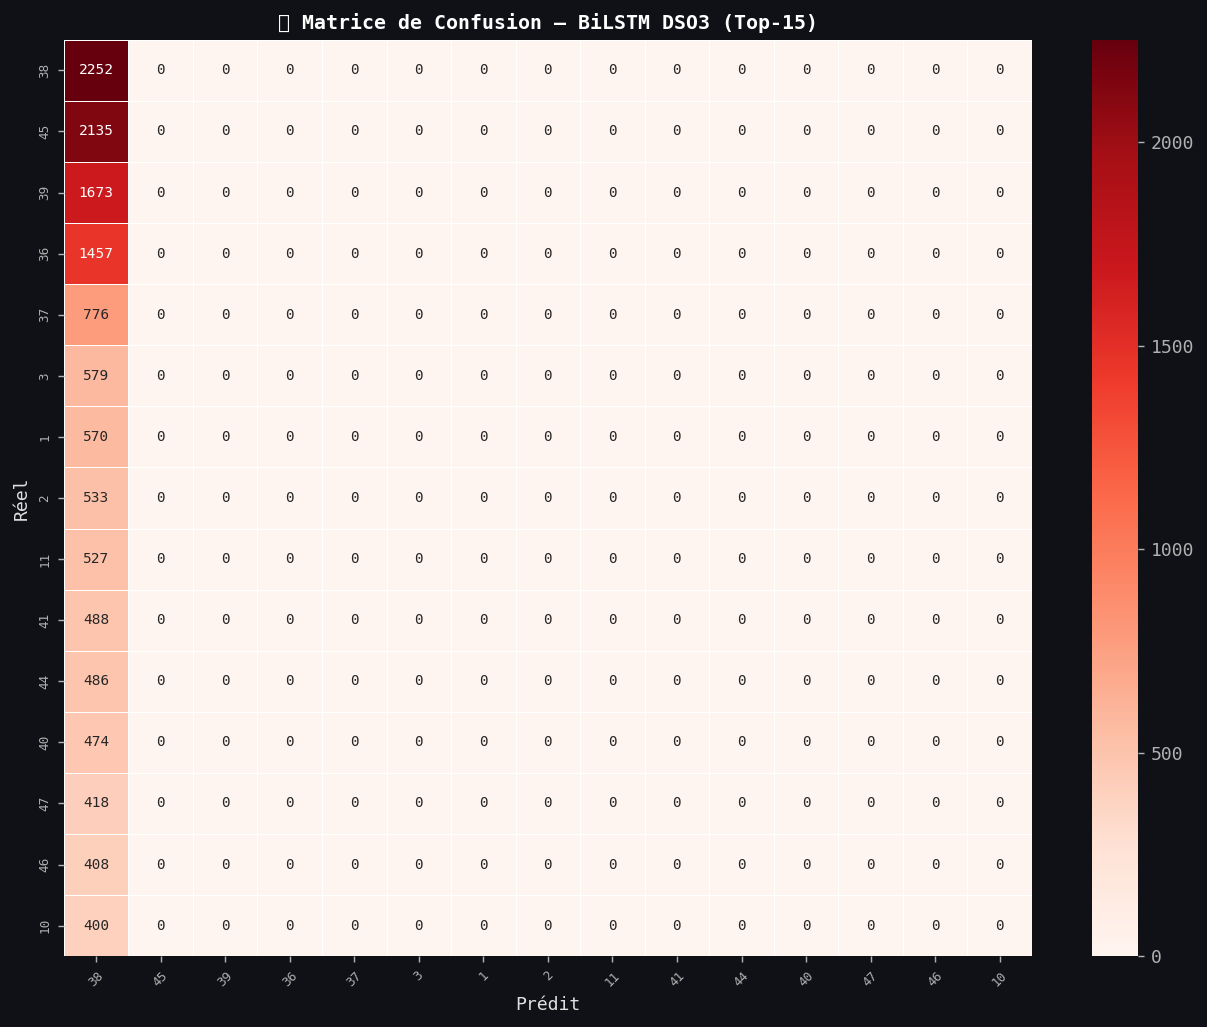

In [12]:
# ── Matrice de Confusion — BiLSTM (Top-15) ───────────────────────────────────
cm_lstm=confusion_matrix(y_test[mask_top],y_pred_lstm[mask_top],labels=top15_cls)
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_lstm,annot=True,fmt='d',cmap='Reds',xticklabels=cell_labels,yticklabels=cell_labels,
    linewidths=0.3,ax=ax,annot_kws={'size':8})
ax.set_xlabel('Prédit',fontsize=10); ax.set_ylabel('Réel',fontsize=10)
ax.tick_params(axis='x',rotation=45,labelsize=7); ax.tick_params(axis='y',labelsize=7)
ax.set_title('🔢 Matrice de Confusion — BiLSTM DSO3 (Top-15)',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_lstm_dso3.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 6 — M5 : TabNet (Pré-entraîné)

In [13]:
print('='*60+'\n  M5 — TabNet DSO3\n'+'='*60)

# ── 1. Sampling pour alléger la mémoire ─────────────────────
N_TN = min(100_000, len(X_train))  # DSO3 est petit, on prend tout ou 100k
idx_tn = np.random.choice(len(X_train), N_TN, replace=False)
X_tr_tn = X_train[idx_tn].astype(np.float32)  # ✅ float32
X_va_tn = X_val.astype(np.float32)
X_te_tn = X_test.astype(np.float32)
y_train_tn = y_train[idx_tn]
print(f'Sample train : {len(X_tr_tn)}')

# ── 2. Pretraining ──────────────────────────────────────────
pt_d3 = TabNetPretrainer(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=5, seed=42
)
pt_d3.fit(
    X_train=X_tr_tn,        # ✅ pas de concat train+val
    eval_set=[X_va_tn],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    pretraining_ratio=0.5
)

# ── 3. Modèle supervisé ─────────────────────────────────────
tabnet_d3 = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3, gamma=1.5,
    n_independent=2, n_shared=2, mask_type='entmax',
    optimizer_fn=torch.optim.Adam,
    optimizer_params={'lr': 2e-3},
    verbose=0, seed=42
)

# ✅ Mini-fit pour initialiser le réseau interne
tabnet_d3.fit(
    X_train=X_tr_tn[:512],
    y_train=y_train_tn[:512].astype(int),
    max_epochs=1, batch_size=512, virtual_batch_size=512
)

# ✅ Transfert des poids encodeur
tabnet_d3.load_weights_from_unsupervised(pt_d3)

# ── 4. Entraînement réel ────────────────────────────────────
tabnet_d3.verbose = 10
tabnet_d3.fit(
    X_train=X_tr_tn,
    y_train=y_train_tn.astype(int),
    eval_set=[(X_va_tn, y_val.astype(int))],
    eval_metric=['accuracy'],
    max_epochs=30, patience=5,
    batch_size=2048, virtual_batch_size=256,
    weights=1
)
y_pred_tn  = tabnet_d3.predict(X_te_tn)
y_proba_tn = tabnet_d3.predict_proba(X_te_tn)
acc_tn  = accuracy_score(y_test, y_pred_tn)
topk_tn = top_k_accuracy_score(y_test, y_proba_tn, k=TOP_K_EVAL,
                                labels=np.arange(N_CLASSES))  # ✅ fix
f1_tn   = f1_score(y_test, y_pred_tn, average='macro', zero_division=0)
metrics_tn = {'model':'TabNet','accuracy':round(acc_tn,4),
              f'top{TOP_K_EVAL}_acc':round(topk_tn,4),'f1_macro':round(f1_tn,4)}
print(f'  Acc={acc_tn:.4f} | Top-{TOP_K_EVAL}={topk_tn:.4f} | F1-macro={f1_tn:.4f}')
tabnet_d3.save_model(os.path.join(MODEL_OUT_DIR,'tabnet_dso3'))


  M5 — TabNet DSO3
Sample train : 91816
epoch 0  | loss: 2817.3861| val_0_unsup_loss_numpy: 399.1868896484375|  0:00:13s
epoch 5  | loss: 84.27491| val_0_unsup_loss_numpy: 78.61437225341797|  0:01:22s
epoch 10 | loss: 78.24719| val_0_unsup_loss_numpy: 77.42578125|  0:02:28s
epoch 15 | loss: 76.92766| val_0_unsup_loss_numpy: 77.30935668945312|  0:03:33s
epoch 20 | loss: 76.83846| val_0_unsup_loss_numpy: 77.09322357177734|  0:04:42s
epoch 25 | loss: 76.75437| val_0_unsup_loss_numpy: 77.10294342041016|  0:05:47s
Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_0_unsup_loss_numpy = 76.88217163085938
epoch 0  | loss: 4.43311 | val_0_accuracy: 0.00966 |  0:00:11s
epoch 10 | loss: 0.99599 | val_0_accuracy: 0.35278 |  0:02:01s
epoch 20 | loss: 0.72522 | val_0_accuracy: 0.58094 |  0:03:47s
Stop training because you reached max_epochs = 30 with best_epoch = 28 and best_val_0_accuracy = 0.64315
  Acc=0.6469 | Top-3=0.9168 | F1-macro=0.7317
Successfully saved mod

'C:\\Users\\THINKPAD\\Desktop\\DATASET\\MODEL_output\\DSO3\\tabnet_dso3.zip'

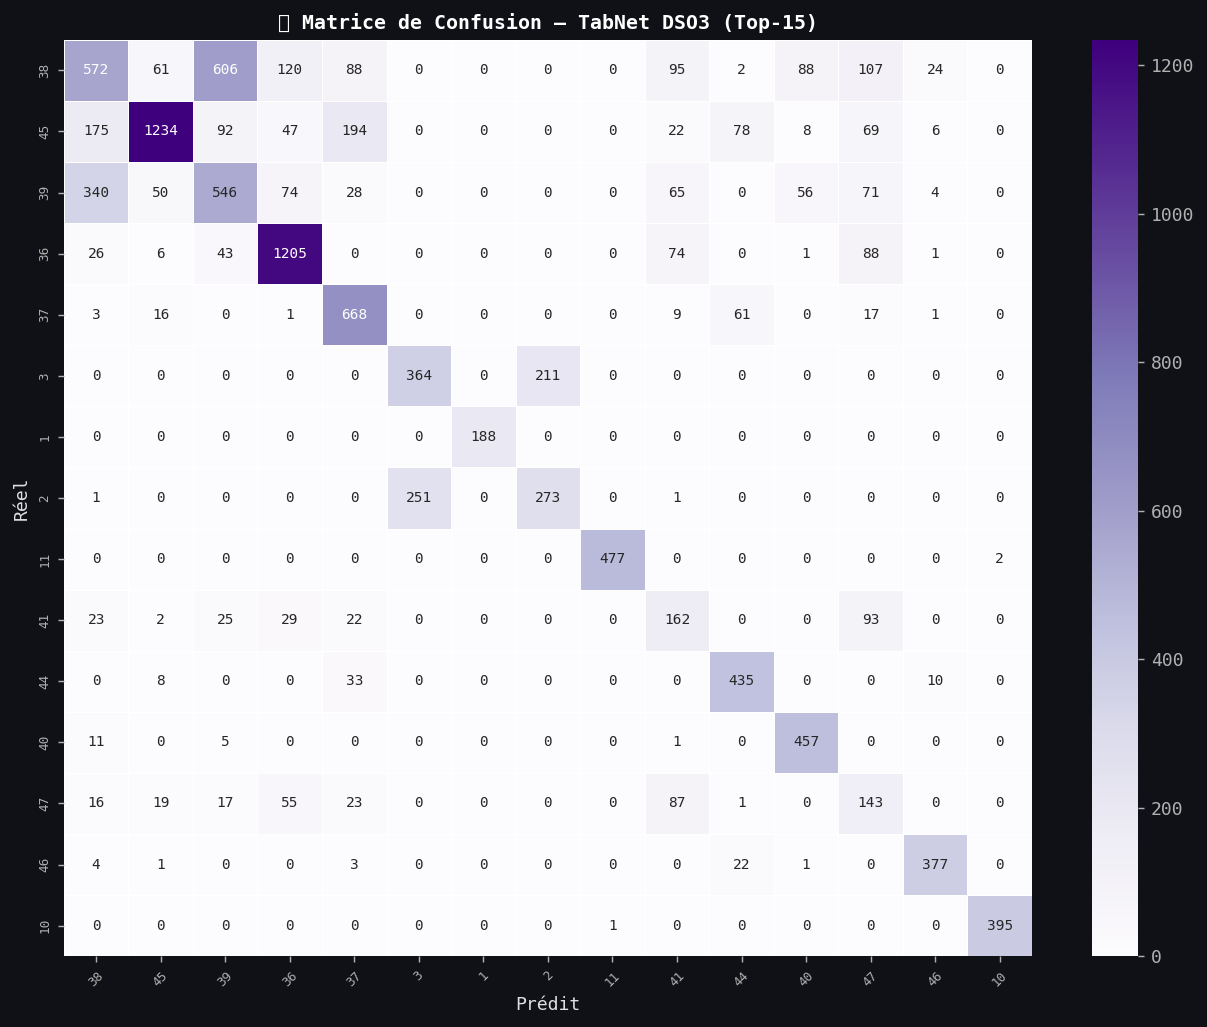

In [14]:
# ── Matrice de Confusion — TabNet (Top-15) ───────────────────────────────────
cm_tn=confusion_matrix(y_test[mask_top],y_pred_tn[mask_top],labels=top15_cls)
fig,ax=plt.subplots(figsize=(10,8))
sns.heatmap(cm_tn,annot=True,fmt='d',cmap='Purples',xticklabels=cell_labels,yticklabels=cell_labels,
    linewidths=0.3,ax=ax,annot_kws={'size':8})
ax.set_xlabel('Prédit',fontsize=10); ax.set_ylabel('Réel',fontsize=10)
ax.tick_params(axis='x',rotation=45,labelsize=7); ax.tick_params(axis='y',labelsize=7)
ax.set_title('🔢 Matrice de Confusion — TabNet DSO3 (Top-15)',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'cm_tabnet_dso3.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()

---
## Section 7 — Comparaison finale

               accuracy  top3_acc  f1_macro
model                                      
XGBoost          0.7848    0.9732    0.8482
LightGBM         0.7638    0.9637    0.8404
Random Forest    0.7318    0.9551    0.7901
BiLSTM           0.1145    0.1656    0.0041
TabNet           0.6469    0.9168    0.7317

🏆 Meilleur (Accuracy) : XGBoost → 0.7848


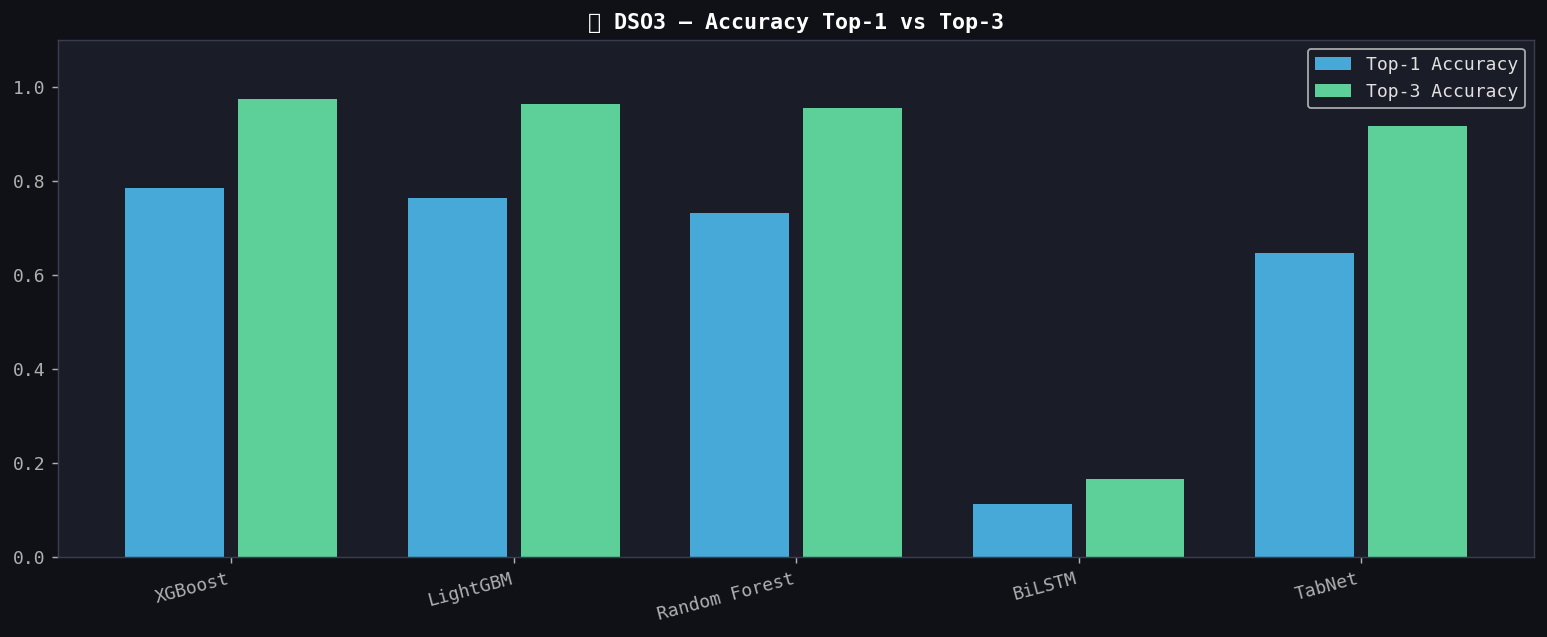

In [15]:
all_metrics=[metrics_xgb,metrics_lgbm,metrics_rf,metrics_lstm,metrics_tn]
df_results=pd.DataFrame(all_metrics).set_index('model')
print(df_results.to_string())
best=df_results['accuracy'].idxmax()
print(f'\n🏆 Meilleur (Accuracy) : {best} → {df_results.loc[best,"accuracy"]:.4f}')
with open(os.path.join(MODEL_OUT_DIR,'results_dso3.json'),'w') as f: json.dump(all_metrics,f,indent=2)

x=np.arange(5); models_list=['XGBoost','LightGBM','Random Forest','BiLSTM','TabNet']
fig,ax=plt.subplots(figsize=(12,5))
ax.bar(x-0.2,df_results['accuracy'],0.35,label='Top-1 Accuracy',color=BLUE,alpha=0.85)
ax.bar(x+0.2,df_results[f'top{TOP_K_EVAL}_acc'],0.35,label=f'Top-{TOP_K_EVAL} Accuracy',color=GREEN,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(models_list,rotation=15,ha='right')
ax.set_title(f'📡 DSO3 — Accuracy Top-1 vs Top-{TOP_K_EVAL}',fontweight='bold')
ax.legend(); ax.set_ylim(0,1.1)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR,'dashboard_dso3.png'),bbox_inches='tight',facecolor='#0F1117')
plt.show()